Epoch 0: 2425 / 10000
Epoch 1: 1689 / 10000
Epoch 2: 5544 / 10000
Epoch 3: 3011 / 10000
Epoch 4: 2624 / 10000
Epoch 5: 5342 / 10000
Epoch 6: 5792 / 10000
Epoch 7: 5675 / 10000
Epoch 8: 6144 / 10000
Epoch 9: 5833 / 10000
Epoch 10: 6077 / 10000
Epoch 11: 6335 / 10000
Epoch 12: 7707 / 10000
Epoch 13: 7623 / 10000
Epoch 14: 7348 / 10000
Epoch 15: 7990 / 10000
Epoch 16: 8124 / 10000
Epoch 17: 8022 / 10000
Epoch 18: 7163 / 10000
Epoch 19: 8155 / 10000
Epoch 20: 7553 / 10000
Epoch 21: 8164 / 10000
Epoch 22: 8493 / 10000
Epoch 23: 8445 / 10000
Epoch 24: 8482 / 10000
Epoch 25: 8567 / 10000
Epoch 26: 8483 / 10000
Epoch 27: 8281 / 10000
Epoch 28: 8490 / 10000
Epoch 29: 8461 / 10000


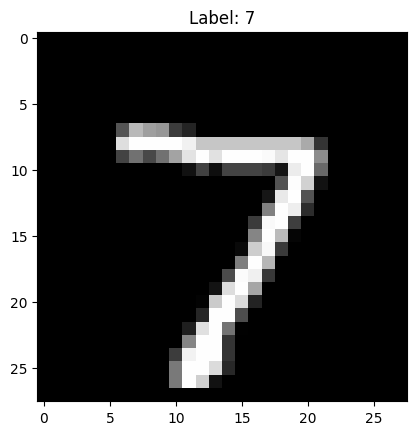

In [2]:
#1st TRY
import pickle #load MNIST dataset
import random #shuffle training data
import numpy as np #maths

# ---------------- Load MNIST from mnist.pkl ----------------
with open('/kaggle/input/mnist0-9/mnist.pkl', 'rb') as f:
    mnist = pickle.load(f, encoding='latin1')  

# Handle tuple format
if len(mnist) == 3:
    (x_train, y_train), _, (x_test, y_test) = mnist
else:
    x_train, y_train, x_test, y_test = mnist

# ---------------- Normalize and reshape ----------------
#because the neural network expects vectors not 2D images
#so each image must become a column vector [(784,1) INSTEAD OF (28,28)]
x_train = x_train.reshape(-1, 784, 1) / 255.0
x_test  = x_test.reshape(-1, 784, 1) / 255.0

# ---------------- Prepare data for your network ----------------
def vectorized_result(j):
    e = np.zeros((10, 1))
    e[j] = 1.0
    return e

training_data = [(x, vectorized_result(y)) for x, y in zip(x_train, y_train)]
test_data = list(zip(x_test, y_test))

# ---------------- Activation Functions ----------------
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_prime(z):
    return sigmoid(z) * (1 - sigmoid(z))

# ---------------- Neural Network Class ----------------
class Network(object):

    def __init__(self, sizes):
        self.num_layers = len(sizes)
        self.sizes = sizes
        self.biases = [np.random.randn(y, 1) for y in sizes[1:]]
        self.weights = [np.random.randn(y, x) for x, y in zip(sizes[:-1], sizes[1:])]

    def feedforward(self, a):
        for b, w in zip(self.biases, self.weights):
            a = sigmoid(np.dot(w, a) + b)
        return a

    def SGD(self, training_data, epochs, mini_batch_size, eta, test_data=None):
        if test_data:
            n_test = len(test_data)
        n = len(training_data)

        for j in range(epochs):
            random.shuffle(training_data)

            mini_batches = [
                training_data[k:k + mini_batch_size]
                for k in range(0, n, mini_batch_size)
            ]

            for mini_batch in mini_batches:
                self.update_mini_batch(mini_batch, eta)

            if test_data:
                print(f"Epoch {j}: {self.evaluate(test_data)} / {n_test}")
            else:
                print(f"Epoch {j} complete")

    def update_mini_batch(self, mini_batch, eta):
        nabla_b = [np.zeros(b.shape) for b in self.biases]
        nabla_w = [np.zeros(w.shape) for w in self.weights]

        for x, y in mini_batch:
            delta_nabla_b, delta_nabla_w = self.backprop(x, y)
            nabla_b = [nb + dnb for nb, dnb in zip(nabla_b, delta_nabla_b)]
            nabla_w = [nw + dnw for nw, dnw in zip(nabla_w, delta_nabla_w)]

        self.weights = [
            w - (eta / len(mini_batch)) * nw
            for w, nw in zip(self.weights, nabla_w)
        ]
        self.biases = [
            b - (eta / len(mini_batch)) * nb
            for b, nb in zip(self.biases, nabla_b)
        ]

    def backprop(self, x, y):
        nabla_b = [np.zeros(b.shape) for b in self.biases]
        nabla_w = [np.zeros(w.shape) for w in self.weights]

        # feedforward
        activation = x
        activations = [x]
        zs = []

        for b, w in zip(self.biases, self.weights):
            z = np.dot(w, activation) + b
            zs.append(z)
            activation = sigmoid(z)
            activations.append(activation)

        # backward pass
        delta = self.cost_derivative(activations[-1], y) * sigmoid_prime(zs[-1])
        nabla_b[-1] = delta
        nabla_w[-1] = np.dot(delta, activations[-2].T)

        for l in range(2, self.num_layers):
            z = zs[-l]
            sp = sigmoid_prime(z)
            delta = np.dot(self.weights[-l + 1].T, delta) * sp
            nabla_b[-l] = delta
            nabla_w[-l] = np.dot(delta, activations[-l - 1].T)

        return nabla_b, nabla_w

    def evaluate(self, test_data):
        test_results = [
            (np.argmax(self.feedforward(x)), y)
            for (x, y) in test_data
        ]
        return sum(int(x == y) for (x, y) in test_results)

    def cost_derivative(self, output_activations, y):
        return output_activations - y

# ---------------- Train Network ----------------
net = Network([784, 30, 10])
net.SGD(training_data, 30, 10, 3.0, test_data=test_data)

#VISUALISATION OF ONE IMAGE
import matplotlib.pyplot as plt
image = x_test[0].reshape(28, 28)
plt.imshow(image, cmap='gray')
plt.title(f"Label: {y_test[0]}")
plt.show()



In [ ]:
#2nd TRY
import pickle #load MNIST dataset
import random #shuffle training data
import numpy as np #maths

# ---------------- Load MNIST from mnist.pkl ----------------
with open('/kaggle/input/mnist0-9/mnist.pkl', 'rb') as f:
    mnist = pickle.load(f, encoding='latin1')  

# Handle tuple format
if len(mnist) == 3:
    (x_train, y_train), _, (x_test, y_test) = mnist
else:
    x_train, y_train, x_test, y_test = mnist

# ---------------- Normalize and reshape ----------------
#because the neural network expects vectors not 2D images
#so each image must become a column vector [(784,1) INSTEAD OF (28,28)]
x_train = x_train.reshape(-1, 784, 1) / 255.0
x_test  = x_test.reshape(-1, 784, 1) / 255.0

# ---------------- Prepare data for your network ----------------
def vectorized_result(j):
    e = np.zeros((10, 1))
    e[j] = 1.0
    return e

training_data = [(x, vectorized_result(y)) for x, y in zip(x_train, y_train)]
test_data = list(zip(x_test, y_test))

# ---------------- Activation Functions ----------------
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_prime(z):
    return sigmoid(z) * (1 - sigmoid(z))

class CrossEntropyCost:
    @staticmethod
    def fn(a, y):
        return np.sum(np.nan_to_num(-y*np.log(a) - (1-y)*np.log(1-a)))

    @staticmethod
    def delta(z, a, y):
        return a - y

# ---------------- Neural Network Class ----------------
class Network(object):

    def __init__(self, sizes, cost=CrossEntropyCost):
        self.num_layers = len(sizes)
        self.sizes = sizes
        self.cost = cost
        self.biases = [np.random.randn(y, 1) for y in sizes[1:]]
        self.weights = [np.random.randn(y, x) for x, y in zip(sizes[:-1], sizes[1:])]

    def feedforward(self, a):
        for b, w in zip(self.biases, self.weights):
            a = sigmoid(np.dot(w, a) + b)
        return a

    def SGD(self, training_data, epochs, mini_batch_size, eta, test_data=None):
        if test_data:
            n_test = len(test_data)
        n = len(training_data)

        # Convert vectorized labels to integers for evaluation
        training_data_eval = [(x, np.argmax(y)) for x, y in training_data]

        training_acc_list = []
        test_acc_list = []

        for j in range(epochs):
            random.shuffle(training_data)

            mini_batches = [
                training_data[k:k + mini_batch_size]
                for k in range(0, n, mini_batch_size)
             ]

            for mini_batch in mini_batches:
                self.update_mini_batch(mini_batch, eta)

            train_acc = self.evaluate(training_data_eval) / n * 100
            training_acc_list.append(train_acc)

            if test_data:
                test_acc = self.evaluate(test_data) / n_test * 100
                test_acc_list.append(test_acc)
                print(f"Epoch {j}: Train={train_acc:.2f}% | Test={test_acc:.2f}%")
            else:
                print(f"Epoch {j} complete")

        return training_acc_list, test_acc_list

    def update_mini_batch(self, mini_batch, eta):
        nabla_b = [np.zeros(b.shape) for b in self.biases]
        nabla_w = [np.zeros(w.shape) for w in self.weights]

        for x, y in mini_batch:
            delta_nabla_b, delta_nabla_w = self.backprop(x, y)
            nabla_b = [nb + dnb for nb, dnb in zip(nabla_b, delta_nabla_b)]
            nabla_w = [nw + dnw for nw, dnw in zip(nabla_w, delta_nabla_w)]

        self.weights = [
            w - (eta / len(mini_batch)) * nw
            for w, nw in zip(self.weights, nabla_w)
        ]
        self.biases = [
            b - (eta / len(mini_batch)) * nb
            for b, nb in zip(self.biases, nabla_b)
        ]

    def backprop(self, x, y):
        nabla_b = [np.zeros(b.shape) for b in self.biases]
        nabla_w = [np.zeros(w.shape) for w in self.weights]

        # feedforward
        activation = x
        activations = [x]
        zs = []

        for b, w in zip(self.biases, self.weights):
            z = np.dot(w, activation) + b
            zs.append(z)
            activation = sigmoid(z)
            activations.append(activation)

        # backward pass
        delta = self.cost.delta(zs[-1], activations[-1], y)
        nabla_b[-1] = delta
        nabla_w[-1] = np.dot(delta, activations[-2].T)

        for l in range(2, self.num_layers):
            z = zs[-l]
            sp = sigmoid_prime(z)
            delta = np.dot(self.weights[-l + 1].T, delta) * sp
            nabla_b[-l] = delta
            nabla_w[-l] = np.dot(delta, activations[-l - 1].T)

        return nabla_b, nabla_w

    def evaluate(self, test_data):
        test_results = [
            (np.argmax(self.feedforward(x)), y)
            for (x, y) in test_data
        ]
        return sum(int(x == y) for (x, y) in test_results)



# ---------------- Train Network ----------------
net = Network([784, 30, 10])
train_acc2, test_acc2 = net.SGD(training_data, 30, 10, 0.5, test_data=test_data)

import matplotlib.pyplot as plt
epochs = range(1, 31)

plt.figure(figsize=(10,6))

plt.plot(epochs, train_acc2, '--o', label="Train Accuracy (No Reg)", color='blue')
plt.plot(epochs, test_acc2, '-o', label="Test Accuracy (No Reg)", color='green')

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Test Accuracy: Without vs With L2 Regularization")
plt.legend()
plt.grid(True)
plt.show()








In [ ]:
#3rd TRY without regularization
import pickle #load MNIST dataset
import random #shuffle training data
import numpy as np #maths

# ---------------- Load MNIST from mnist.pkl ----------------
with open('/kaggle/input/mnist0-9/mnist.pkl', 'rb') as f:
    mnist = pickle.load(f, encoding='latin1')  

# Handle tuple format
if len(mnist) == 3:
    (x_train, y_train), _, (x_test, y_test) = mnist
else:
    x_train, y_train, x_test, y_test = mnist

# ---------------- Normalize and reshape ----------------
#because the neural network expects vectors not 2D images
#so each image must become a column vector [(784,1) INSTEAD OF (28,28)]
x_train = x_train.reshape(-1, 784, 1) / 255.0
x_test  = x_test.reshape(-1, 784, 1) / 255.0

# ---------------- Prepare data for your network ----------------
def vectorized_result(j):
    e = np.zeros((10, 1))
    e[j] = 1.0
    return e

training_data = [(x, vectorized_result(y)) for x, y in zip(x_train, y_train)]
test_data = list(zip(x_test, y_test))

# ---------------- Activation Functions ----------------
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_prime(z):
    return sigmoid(z) * (1 - sigmoid(z))

class CrossEntropyCost:
    @staticmethod
    def fn(a, y):
        return np.sum(np.nan_to_num(-y*np.log(a) - (1-y)*np.log(1-a)))

    @staticmethod
    def delta(z, a, y):
        return a - y

# ---------------- Neural Network Class ----------------
class Network(object):

    def __init__(self, sizes, cost=CrossEntropyCost):
        self.num_layers = len(sizes)
        self.sizes = sizes
        self.cost = cost
        self.biases = [np.random.randn(y, 1) for y in sizes[1:]]
        self.weights = [np.random.randn(y, x) for x, y in zip(sizes[:-1], sizes[1:])]

    def feedforward(self, a):
        for b, w in zip(self.biases, self.weights):
            a = sigmoid(np.dot(w, a) + b)
        return a

    def SGD(self, training_data, epochs, mini_batch_size, eta, test_data=None):
        if test_data:
            n_test = len(test_data)
        n = len(training_data)

        # Convert vectorized labels to integers for evaluation
        training_data_eval = [(x, np.argmax(y)) for x, y in training_data]

        training_acc_list = []
        test_acc_list = []

        for j in range(epochs):
            random.shuffle(training_data)

            mini_batches = [
                training_data[k:k + mini_batch_size]
                for k in range(0, n, mini_batch_size)
             ]

            for mini_batch in mini_batches:
                self.update_mini_batch(mini_batch, eta)

            train_acc = self.evaluate(training_data_eval) / n * 100
            training_acc_list.append(train_acc)

            if test_data:
                test_acc = self.evaluate(test_data) / n_test * 100
                test_acc_list.append(test_acc)
                print(f"Epoch {j}: Train={train_acc:.2f}% | Test={test_acc:.2f}%")
            else:
                print(f"Epoch {j} complete")

        return training_acc_list, test_acc_list

    def update_mini_batch(self, mini_batch, eta):
        nabla_b = [np.zeros(b.shape) for b in self.biases]
        nabla_w = [np.zeros(w.shape) for w in self.weights]

        for x, y in mini_batch:
            delta_nabla_b, delta_nabla_w = self.backprop(x, y)
            nabla_b = [nb + dnb for nb, dnb in zip(nabla_b, delta_nabla_b)]
            nabla_w = [nw + dnw for nw, dnw in zip(nabla_w, delta_nabla_w)]

        self.weights = [
            w - (eta / len(mini_batch)) * nw
            for w, nw in zip(self.weights, nabla_w)
        ]
        self.biases = [
            b - (eta / len(mini_batch)) * nb
            for b, nb in zip(self.biases, nabla_b)
        ]

    def backprop(self, x, y):
        nabla_b = [np.zeros(b.shape) for b in self.biases]
        nabla_w = [np.zeros(w.shape) for w in self.weights]

        # feedforward
        activation = x
        activations = [x]
        zs = []

        for b, w in zip(self.biases, self.weights):
            z = np.dot(w, activation) + b
            zs.append(z)
            activation = sigmoid(z)
            activations.append(activation)

        # backward pass
        delta = self.cost.delta(zs[-1], activations[-1], y)
        nabla_b[-1] = delta
        nabla_w[-1] = np.dot(delta, activations[-2].T)

        for l in range(2, self.num_layers):
            z = zs[-l]
            sp = sigmoid_prime(z)
            delta = np.dot(self.weights[-l + 1].T, delta) * sp
            nabla_b[-l] = delta
            nabla_w[-l] = np.dot(delta, activations[-l - 1].T)

        return nabla_b, nabla_w

    def evaluate(self, test_data):
        test_results = [
            (np.argmax(self.feedforward(x)), y)
            for (x, y) in test_data
        ]
        return sum(int(x == y) for (x, y) in test_results)



# ---------------- Train Network ----------------
net = Network([784, 30, 10])
# Use only first 1000 training images
train_acc2, test_acc2 = net.SGD(training_data[:1000], 400, 10, 0.5, test_data=test_data)

import matplotlib.pyplot as plt
epochs = range(1, 401)

plt.figure(figsize=(10,6))

plt.plot(epochs, train_acc2, '--o', label="Train Accuracy (No Reg)", color='blue')
plt.plot(epochs, test_acc2, '-o', label="Test Accuracy (No Reg)", color='green')

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Test Accuracy: Without vs With L2 Regularization")
plt.legend()
plt.grid(True)
plt.show()








In [ ]:
#3rd TRY with regularization
import pickle #load MNIST dataset
import random #shuffle training data
import numpy as np #maths

# ---------------- Load MNIST from mnist.pkl ----------------
with open('/kaggle/input/mnist0-9/mnist.pkl', 'rb') as f:
    mnist = pickle.load(f, encoding='latin1')  

# Handle tuple format
if len(mnist) == 3:
    (x_train, y_train), _, (x_test, y_test) = mnist
else:
    x_train, y_train, x_test, y_test = mnist

# ---------------- Normalize and reshape ----------------
#because the neural network expects vectors not 2D images
#so each image must become a column vector [(784,1) INSTEAD OF (28,28)]
x_train = x_train.reshape(-1, 784, 1) / 255.0
x_test  = x_test.reshape(-1, 784, 1) / 255.0

# ---------------- Prepare data for your network ----------------
def vectorized_result(j):
    e = np.zeros((10, 1))
    e[j] = 1.0
    return e

training_data = [(x, vectorized_result(y)) for x, y in zip(x_train, y_train)]
test_data = list(zip(x_test, y_test))

# ---------------- Activation Functions ----------------
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_prime(z):
    return sigmoid(z) * (1 - sigmoid(z))

class CrossEntropyCost:
    @staticmethod
    def fn(a, y):
        return np.sum(np.nan_to_num(-y*np.log(a) - (1-y)*np.log(1-a)))

    @staticmethod
    def delta(z, a, y):
        return a - y

# ---------------- Neural Network Class ----------------
class Network(object):

    def __init__(self, sizes, cost=CrossEntropyCost):
        self.num_layers = len(sizes)
        self.sizes = sizes
        self.cost = cost
        self.biases = [np.random.randn(y, 1) for y in sizes[1:]]
        self.weights = [np.random.randn(y, x) for x, y in zip(sizes[:-1], sizes[1:])]

    def feedforward(self, a):
        for b, w in zip(self.biases, self.weights):
            a = sigmoid(np.dot(w, a) + b)
        return a

    def SGD(self, training_data, epochs, mini_batch_size, eta, test_data=None, lmbda=0.0):
        if test_data:
            n_test = len(test_data)
        n = len(training_data)

        # Convert vectorized labels to integers for evaluation
        training_data_eval = [(x, np.argmax(y)) for x, y in training_data]

        training_acc_list = []
        test_acc_list = []

        for j in range(epochs):
            random.shuffle(training_data)

            mini_batches = [
                training_data[k:k + mini_batch_size]
                for k in range(0, n, mini_batch_size)
             ]

            for mini_batch in mini_batches:
                self.update_mini_batch(mini_batch, eta, lmbda, n)

            train_acc = self.evaluate(training_data_eval) / n * 100
            training_acc_list.append(train_acc)

            if test_data:
                test_acc = self.evaluate(test_data) / n_test * 100
                test_acc_list.append(test_acc)
                print(f"Epoch {j}: Train={train_acc:.2f}% | Test={test_acc:.2f}%")
            else:
                print(f"Epoch {j} complete")

        return training_acc_list, test_acc_list

    def update_mini_batch(self, mini_batch, eta, lmbda, n):
        nabla_b = [np.zeros(b.shape) for b in self.biases]
        nabla_w = [np.zeros(w.shape) for w in self.weights]

        for x, y in mini_batch:
            delta_nabla_b, delta_nabla_w = self.backprop(x, y)
            nabla_b = [nb + dnb for nb, dnb in zip(nabla_b, delta_nabla_b)]
            nabla_w = [nw + dnw for nw, dnw in zip(nabla_w, delta_nabla_w)]

        self.weights = [
            (1 - eta * (lmbda / n)) * w - (eta / len(mini_batch)) * nw
            for w, nw in zip(self.weights, nabla_w)
        ]
        self.biases = [
            b - (eta / len(mini_batch)) * nb
            for b, nb in zip(self.biases, nabla_b)
        ]

    def backprop(self, x, y):
        nabla_b = [np.zeros(b.shape) for b in self.biases]
        nabla_w = [np.zeros(w.shape) for w in self.weights]

        # feedforward
        activation = x
        activations = [x]
        zs = []

        for b, w in zip(self.biases, self.weights):
            z = np.dot(w, activation) + b
            zs.append(z)
            activation = sigmoid(z)
            activations.append(activation)

        # backward pass
        delta = self.cost.delta(zs[-1], activations[-1], y)
        nabla_b[-1] = delta
        nabla_w[-1] = np.dot(delta, activations[-2].T)

        for l in range(2, self.num_layers):
            z = zs[-l]
            sp = sigmoid_prime(z)
            delta = np.dot(self.weights[-l + 1].T, delta) * sp
            nabla_b[-l] = delta
            nabla_w[-l] = np.dot(delta, activations[-l - 1].T)

        return nabla_b, nabla_w

    def evaluate(self, test_data):
        test_results = [
            (np.argmax(self.feedforward(x)), y)
            for (x, y) in test_data
        ]
        return sum(int(x == y) for (x, y) in test_results)



# ---------------- Train Network ----------------
net = Network([784, 30, 10])
# Use only first 1000 training images
train_acc2, test_acc2 = net.SGD(training_data[:1000], 400, 10, 0.5, test_data=test_data, lmbda=0.1)

import matplotlib.pyplot as plt
epochs = range(1, 401)

plt.figure(figsize=(10,6))

plt.plot(epochs, train_acc2, '--o', label="Train Accuracy (With L2)", color='blue')
plt.plot(epochs, test_acc2, '-o', label="Test Accuracy (With L2)", color='green')

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Test Accuracy: Without vs With L2 Regularization")
plt.legend()
plt.grid(True)
plt.show()








In [ ]:
import pickle
import random
import numpy as np

np.random.seed(42)

# ===============================
# LOAD MNIST (Correct for Kaggle)
# ===============================

with open('/kaggle/input/mnist0-9/mnist.pkl', 'rb') as f:
    training_set, validation_set, test_set = pickle.load(f, encoding='latin1')

x_train, y_train = training_set
x_test, y_test = test_set

# reshape images
x_train = [np.reshape(x, (784,1)) for x in x_train]
x_test = [np.reshape(x, (784,1)) for x in x_test]

# ===============================
# LABEL VECTORIZATION
# ===============================

def vectorized_result(j):
    e = np.zeros((10,1))
    e[j] = 1.0
    return e

training_data = list(zip(x_train,[vectorized_result(y) for y in y_train]))
test_data = list(zip(x_test,y_test))

# ===============================
# COST FUNCTIONS
# ===============================

class QuadraticCost:

    @staticmethod
    def fn(a,y):
        return 0.5*np.linalg.norm(a-y)**2

    @staticmethod
    def delta(z,a,y):
        return (a-y)*sigmoid_prime(z)


class CrossEntropyCost:

    @staticmethod
    def fn(a,y):
        return np.sum(np.nan_to_num(-y*np.log(a)-(1-y)*np.log(1-a)))

    @staticmethod
    def delta(z,a,y):
        return (a-y)

# ===============================
# ACTIVATION
# ===============================

def sigmoid(z):
    return 1.0/(1.0+np.exp(-z))

def sigmoid_prime(z):
    return sigmoid(z)*(1-sigmoid(z))

# ===============================
# NEURAL NETWORK
# ===============================

class Network:

    def __init__(self,sizes,cost=CrossEntropyCost,strategy="none"):
        self.num_layers=len(sizes)
        self.sizes=sizes
        self.cost=cost
        self.strategy=strategy
        self.default_weight_initializer()

    def default_weight_initializer(self):

        self.biases=[np.random.randn(y,1) for y in self.sizes[1:]]

        self.weights=[np.random.randn(y,x)/np.sqrt(x)
                      for x,y in zip(self.sizes[:-1],self.sizes[1:])]

    # ===============================
    # FORWARD PASS
    # ===============================

    def feedforward(self,a):

        for b,w in zip(self.biases,self.weights):
            a=sigmoid(np.dot(w,a)+b)

        return a

    # ===============================
    # STOCHASTIC GRADIENT DESCENT
    # ===============================

    def SGD(self,training_data,epochs,mini_batch_size,eta,
            lmbda=0.0,evaluation_data=None):

        n=len(training_data)

        if evaluation_data:
            n_data=len(evaluation_data)

        for j in range(epochs):

            random.shuffle(training_data)

            mini_batches=[training_data[k:k+mini_batch_size]
                          for k in range(0,n,mini_batch_size)]

            for mini_batch in mini_batches:
                self.update_mini_batch(mini_batch,eta,lmbda,n)

            if evaluation_data:
                accuracy=self.accuracy(evaluation_data)
                print(f"Epoch {j}: {accuracy} / {n_data}")

        if evaluation_data:
            print("Final accuracy:",self.accuracy(evaluation_data),"/",n_data)

    # ===============================
    # MINI BATCH UPDATE
    # ===============================

    def update_mini_batch(self,mini_batch,eta,lmbda,n):

        nabla_b=[np.zeros(b.shape) for b in self.biases]
        nabla_w=[np.zeros(w.shape) for w in self.weights]

        for x,y in mini_batch:

            delta_nabla_b,delta_nabla_w=self.backprop(x,y)

            nabla_b=[nb+dnb for nb,dnb in zip(nabla_b,delta_nabla_b)]
            nabla_w=[nw+dnw for nw,dnw in zip(nabla_w,delta_nabla_w)]

        new_weights=[]

        for w,nw in zip(self.weights,nabla_w):

            if self.strategy=="l2":

                w=(1-eta*(lmbda/n))*w-(eta/len(mini_batch))*nw

            elif self.strategy=="l1":

                w=w-(eta*(lmbda/n))*np.sign(w)-(eta/len(mini_batch))*nw

            else:

                w=w-(eta/len(mini_batch))*nw

            new_weights.append(w)

        self.weights=new_weights

        self.biases=[b-(eta/len(mini_batch))*nb
                     for b,nb in zip(self.biases,nabla_b)]

    # ===============================
    # BACKPROPAGATION
    # ===============================

    def backprop(self,x,y):

        nabla_b=[np.zeros(b.shape) for b in self.biases]
        nabla_w=[np.zeros(w.shape) for w in self.weights]

        activation=x
        activations=[x]
        zs=[]

        for b,w in zip(self.biases,self.weights):

            z=np.dot(w,activation)+b
            zs.append(z)

            activation=sigmoid(z)
            activations.append(activation)

        delta=(self.cost).delta(zs[-1],activations[-1],y)

        nabla_b[-1]=delta
        nabla_w[-1]=np.dot(delta,activations[-2].T)

        for l in range(2,self.num_layers):

            z=zs[-l]
            sp=sigmoid_prime(z)

            delta=np.dot(self.weights[-l+1].T,delta)*sp

            nabla_b[-l]=delta
            nabla_w[-l]=np.dot(delta,activations[-l-1].T)

        return (nabla_b,nabla_w)

    # ===============================
    # ACCURACY
    # ===============================

    def accuracy(self,data):

        results=[(np.argmax(self.feedforward(x)),y) for x,y in data]

        return sum(int(x==y) for x,y in results)

# ===============================
# HYPERPARAMETER EXPERIMENTS
# ===============================

strategies=["none","l2","l1"]
etas=[0.1,0.5]
lambdas=[0.0,0.1,1.0]

for strategy in strategies:

    for eta in etas:

        for lmbda in lambdas:

            print("\n"+"="*50)
            print("Strategy:",strategy," eta:",eta," lambda:",lmbda)

            net=Network([784,100,10],strategy=strategy)

            net.SGD(training_data,
                    epochs=30,
                    mini_batch_size=32,
                    eta=eta,
                    lmbda=lmbda,
                    evaluation_data=test_data)